<a href="https://colab.research.google.com/github/babiologa/Bioestat-stica/blob/main/tarefa05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Bioestatística

##Barbara Aimy Baldin - 16856147
##Dante Gomes Soares de Morais - 16883610
##Marina de Oliveira Cappato - 16891112

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [31]:
df = pd.read_excel("tarefa05.xlsx", sheet_name="Eugenia")
df.head()

,Bloco,Tratamento,Recipiente,Explante,Brotos,Folhas
0,1,0,1,1,2,6
1,1,0,1,2,1,8
2,1,0,1,3,0,0
3,1,0,1,4,1,0
4,1,0,1,5,2,0


In [ ]:
df.info()

In [4]:
print("Brotos")
print("Mínimo:", df["Brotos"].min())
print("Máximo:", df["Brotos"].max())

print("\nFolhas")
print("Mínimo:", df["Folhas"].min())
print("Máximo:", df["Folhas"].max())

Brotos
Mínimo: 0
Máximo: 6

Folhas
Mínimo: 0
Máximo: 46


In [ ]:
quartis = df[["Brotos", "Folhas"]].quantile([0.25, 0.50, 0.75])

quartis

In [9]:
df.groupby("Tratamento")["Brotos"].mean()
df.groupby("Tratamento")["Folhas"].mean()

,Folhas
Tratamento,
0,5.400000
1,15.000000
2,11.700000
3,9.066667


In [10]:
df.groupby("Tratamento")[["Brotos", "Folhas"]].mean()

,Brotos,Folhas
Tratamento,,
0,0.933333,5.400000
1,1.866667,15.000000
2,2.266667,11.700000
3,1.700000,9.066667


In [12]:
for tratamento, grupo in df.groupby("Tratamento"):
    amplitude = grupo["Brotos"].max() - grupo["Brotos"].min()
    print("Tratamento", tratamento, "- amplitude dos brotos:", amplitude)

Tratamento 0 - amplitude dos brotos: 2
Tratamento 1 - amplitude dos brotos: 6
Tratamento 2 - amplitude dos brotos: 4
Tratamento 3 - amplitude dos brotos: 4


In [11]:
for tratamento, grupo in df.groupby("Tratamento"):
    amplitude = grupo["Folhas"].max() - grupo["Folhas"].min()
    print("Tratamento", tratamento, "- amplitude das folhas:", amplitude)

Tratamento 0 - amplitude das folhas: 20
Tratamento 1 - amplitude das folhas: 42
Tratamento 2 - amplitude das folhas: 32
Tratamento 3 - amplitude das folhas: 46


In [14]:
df.groupby("Tratamento")["Brotos"].var()


,Brotos
Tratamento,
0,0.685057
1,1.774713
2,2.271264
3,2.148276


In [15]:
df.groupby("Tratamento")["Folhas"].var()

,Folhas
Tratamento,
0,40.593103
1,123.793103
2,82.148276
3,123.857471


In [16]:
df.groupby("Tratamento")["Brotos"].std()

,Brotos
Tratamento,
0,0.827682
1,1.332183
2,1.507071
3,1.465700


In [17]:
df.groupby("Tratamento")["Folhas"].std()

,Folhas
Tratamento,
0,6.371272
1,11.126235
2,9.063569
3,11.129127


In [18]:
for tratamento, grupo in df.groupby("Tratamento"):
    media = grupo["Brotos"].mean()
    desvio = grupo["Brotos"].std()
    cv = (desvio / media) * 100

    print("Tratamento", tratamento, "- CV:", round(cv, 2), "%")

Tratamento 0 - CV: 88.68 %
Tratamento 1 - CV: 71.37 %
Tratamento 2 - CV: 66.49 %
Tratamento 3 - CV: 86.22 %


In [19]:
for tratamento, grupo in df.groupby("Tratamento"):
    media = grupo["Folhas"].mean()
    desvio = grupo["Folhas"].std()
    cv = (desvio / media) * 100

    print("Tratamento", tratamento, "- CV:", round(cv, 2), "%")

Tratamento 0 - CV: 117.99 %
Tratamento 1 - CV: 74.17 %
Tratamento 2 - CV: 77.47 %
Tratamento 3 - CV: 122.75 %


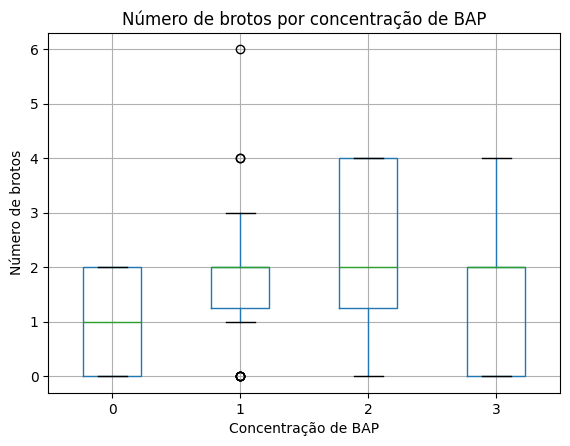

In [20]:
df.boxplot(column="Brotos", by="Tratamento")

plt.title("Número de brotos por concentração de BAP")
plt.suptitle("")
plt.xlabel("Concentração de BAP")
plt.ylabel("Número de brotos")

plt.show()

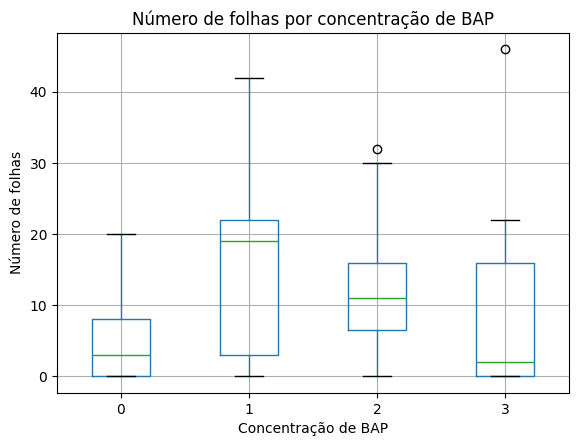

In [21]:
df.boxplot(column="Folhas", by="Tratamento")

plt.title("Número de folhas por concentração de BAP")
plt.suptitle("")
plt.xlabel("Concentração de BAP")
plt.ylabel("Número de folhas")

plt.show()

In [24]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

modelo_brotos = ols(
    "Brotos ~ C(Tratamento) + C(Bloco)",
    data=df
).fit()

anova_lm(modelo_brotos, typ=2)

,sum_sq,df,F,PR(>F)
C(Tratamento),28.091667,3.0,5.644011,0.001230
C(Bloco),15.341667,5.0,1.849414,0.109039
Residual,184.158333,111.0,NaN,NaN


In [25]:
modelo_folhas = ols(
    "Folhas ~ C(Tratamento) + C(Bloco)",
    data=df
).fit()

anova_lm(modelo_folhas, typ=2)

,sum_sq,df,F,PR(>F)
C(Tratamento),1487.425000,3.0,5.661353,0.001204
C(Bloco),1020.241667,5.0,2.329912,0.047086
Residual,9721.125000,111.0,NaN,NaN


In [27]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_brotos = pairwise_tukeyhsd(
    df["Brotos"],
    df["Tratamento"]
)

print(tukey_brotos)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     0      1   0.9333 0.0338  0.0507  1.816   True
     0      2   1.3333 0.0008  0.4507  2.216   True
     0      3   0.7667 0.1125  -0.116 1.6493  False
     1      2      0.4 0.6398 -0.4826 1.2826  False
     1      3  -0.1667 0.9607 -1.0493  0.716  False
     2      3  -0.5667 0.3423 -1.4493  0.316  False
---------------------------------------------------


In [28]:
tukey_folhas = pairwise_tukeyhsd(
    df["Folhas"],
    df["Tratamento"]
)

print(tukey_folhas)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     0      1      9.6  0.001   3.1235 16.0765   True
     0      2      6.3 0.0597  -0.1765 12.7765  False
     0      3   3.6667 0.4554  -2.8098 10.1432  False
     1      2     -3.3  0.547  -9.7765  3.1765  False
     1      3  -5.9333 0.0851 -12.4098  0.5432  False
     2      3  -2.6333 0.7145  -9.1098  3.8432  False
-----------------------------------------------------


In [29]:
q1 = df["Brotos"].quantile(0.25)
q3 = df["Brotos"].quantile(0.75)

iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

df[(df["Brotos"] < limite_inferior) |
   (df["Brotos"] > limite_superior)]

,Bloco,Tratamento,Recipiente,Explante,Brotos,Folhas
107,6,1,2,3,6,42


In [30]:
q1 = df["Folhas"].quantile(0.25)
q3 = df["Folhas"].quantile(0.75)

iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

df[(df["Folhas"] < limite_inferior) |
   (df["Folhas"] > limite_superior)]

,Bloco,Tratamento,Recipiente,Explante,Brotos,Folhas
35,2,3,4,1,4,46


#Perguntas de pesquisa

#1 -
Sim. Pelo critério de 1,5 × IQR, foram encontrados dois valores atípicos:

Brotos: mínimo = 0 e máximo = 6. O valor 6 brotos, no tratamento de 1 mg/L, aparece como atípico.
Folhas: mínimo = 0 e máximo = 46. O valor 46 folhas, no tratamento de 3 mg/L, aparece como atípico.

O valor mínimo 0 significa que alguns explantes não produziram brotos ou folhas. Já os valores máximos representam os explantes que tiveram a maior resposta ao tratamento.

#2 -
Para brotos:

2º quartil (mediana) = 2
3º quartil = 2

Isso significa que 50% dos explantes apresentaram até 2 brotos e 75% apresentaram até 2 brotos.

Para folhas:

2º quartil (mediana) = 10
3º quartil = 18

Ou seja, metade dos explantes apresentou até 10 folhas e 75% apresentou até 18 folhas.

#3 -
A concentração de 2 mg/L apresentou a maior média de brotos, enquanto 1 mg/L apresentou a maior média de folhas.

#4 -
Pelos desvios-padrão e pelos boxplots, os tratamentos de 1 e 3 mg/L apresentam maior variabilidade para folhas.

Para brotos, o tratamento de 0 mg/L apresenta uma variabilidade relativamente alta em relação à sua média, enquanto o tratamento de 2 mg/L é mais consistente.

#5 -
Pelo teste de Tukey a 5%:

Para brotos:

Controle × 1 mg/L: há diferença significativa (p = 0,0338).
Controle × 2 mg/L: há diferença significativa (p = 0,0008).
Controle × 3 mg/L: não há diferença significativa (p = 0,1125).

Para folhas:

Controle × 1 mg/L: há diferença significativa (p = 0,0010).
Controle × 2 mg/L: não há diferença significativa (p = 0,0597).
Controle × 3 mg/L: não há diferença significativa (p = 0,4554).

Então, comparando diretamente com o controle, a dose de 1 mg/L foi a única que apresentou diferença significativa tanto para brotos quanto para folhas.

#6 -
A maior média de folhas ocorreu em 1 mg/L, com 15,0 folhas por explante.

A menor média ocorreu no controle (0 mg/L), com 5,4 folhas por explante.

#7 -
O tratamento de 2 mg/L teve a maior média de brotos (2,27), mas não teve a maior média de folhas (11,70).

Já o tratamento de 1 mg/L teve menos brotos em média (1,87), mas apresentou a maior quantidade de folhas (15,0).

Portanto, existe uma diferença entre a produção de brotos e de folhas: mais brotação não significa necessariamente mais folhas. O tratamento de 2 mg/L é o melhor exemplo disso.

#8 -
Para brotos, o tratamento de 2 mg/L apresentou a maior variância e o maior desvio-padrão.

Para folhas, os tratamentos de 1 e 3 mg/L apresentaram a maior variância e praticamente o mesmo desvio-padrão. O tratamento de 3 mg/L também teve a maior amplitude, de 46.

#9 -
Para brotos, o maior CV foi no controle (88,68%), seguido de 3 mg/L.

Para folhas, o maior CV foi em 3 mg/L (122,75%), seguido do controle.

Os tratamentos de 1 e 2 mg/L apresentam menor variabilidade relativa, principalmente em comparação com o controle e 3 mg/L.

#10 -
Os boxplots mostram que a mediana de brotos fica próxima de 2 na maior parte dos tratamentos. O tratamento de 0 mg/L possui valores mais baixos.

Também é possível perceber uma dispersão maior nos dados de folhas, principalmente nos tratamentos de 1 e 3 mg/L.

Além disso, os boxplots permitem visualizar os possíveis valores atípicos. Para brotos aparece o valor de 6 brotos no tratamento de 1 mg/L, enquanto para folhas aparece o valor de 46 folhas no tratamento de 3 mg/L.

#11 -
Os dados de brotos apresentam uma concentração grande em valores baixos, principalmente entre 0 e 2, com alguns valores maiores. Isso indica uma tendência de assimetria para a direita, especialmente no tratamento de 1 mg/L por causa do valor 6.

Para folhas, a dispersão é maior. Os tratamentos de 1 e 3 mg/L são os mais dispersos. O tratamento de 3 mg/L apresenta a maior amplitude e o valor extremo de 46 folhas.

Os dados parecem mais concentrados nos tratamentos de 0 mg/L para brotos e 1–2 mg/L para folhas, enquanto 1 e 3 mg/L apresentam maior dispersão das folhas.